# Google Play Store Reviews Sentiment Analysis (Google Drive Version)
This notebook replicates the sentiment analysis workflow, configured to run in Google Colab with Google Drive mounted.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt


In [3]:
# Define the path to your dataset in Google Drive
# CHANGE THIS PATH to match where you uploaded the file in your Drive
file_path = '/content/drive/MyDrive/dataset_google-play-store-reviews-scraper_2026-05-07_16-23-08-366.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,rating,reviewer,date,body,helpfulCounts,appVersion,language,appId
0,3,Laily Yuliani,2026-03-30,When we pause the application during the data ...,2,6.17.1,en,com.kai.kaiticketing
1,2,Andre Saftari,2026-03-13,So dumb. There is a bug where there are a tick...,0,6.17.0,en,com.kai.kaiticketing
2,1,Nurul Huda,2026-03-22,"Why you change ""Tambah tiket"" feature matching...",4,6.17.1,en,com.kai.kaiticketing
3,4,S.Callisto,2026-04-11,All good. But it lags so much. I've tried to p...,0,6.17.1,en,com.kai.kaiticketing
4,1,Fellyn Lim,2026-04-20,"Booking errors, that say ""Cannot Booking More ...",2,6.17.1,en,com.kai.kaiticketing


In [4]:
def get_sentiment(text):
    if not isinstance(text, str):
        return 'neutral'
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.05:
        return 'positive'
    elif polarity < -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply sentiment analysis on the 'body' column
df['sentiment'] = df['body'].apply(get_sentiment)

print("Sentiment counts:")
print(df['sentiment'].value_counts())

Sentiment counts:
sentiment
positive    192
negative    175
neutral     133
Name: count, dtype: int64


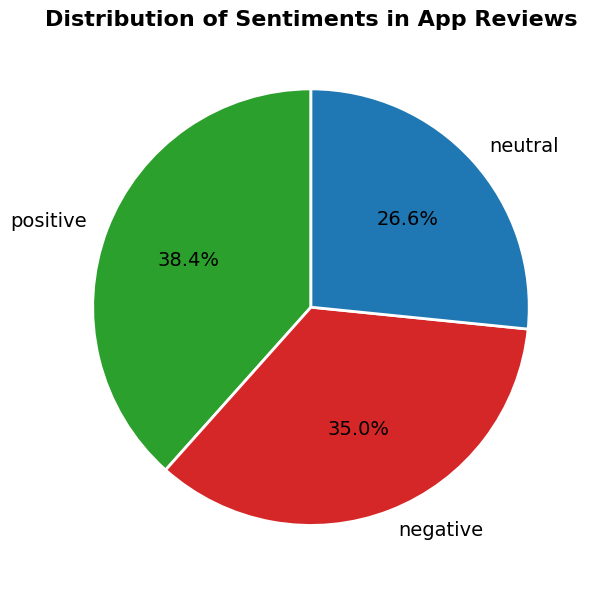

In [5]:
# Plotting the sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
color_map = {'positive': '#2ca02c', 'negative': '#d62728', 'neutral': '#1f77b4'}

plt.figure(figsize=(8, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=[color_map.get(x, '#333333') for x in sentiment_counts.index],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 14})
plt.title("Distribution of Sentiments in App Reviews", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Export to CSV exactly like the example, saving directly to Google Drive
output_filename = '/content/drive/MyDrive/Hasil_Analisis_GooglePlay_Reviews.csv'
df.to_csv(output_filename, index=False)
print(f"✅ Comprehensive data successfully saved to '{output_filename}'")

✅ Comprehensive data successfully saved to '/content/drive/MyDrive/Hasil_Analisis_GooglePlay_Reviews.csv'
